# Flipkart E-Commerce Sales Analysis — June 2026

End-to-end business analysis using Python and Pandas, covering sales trends, product/SKU performance, geographic performance, fulfilment, AOV, Pareto analysis and discount impact.

> **Portfolio note:** The original marketplace dataset and local SQL Server connection details are not included in this public repository. The notebook retains the completed analysis and results.

In [ ]:
import pandas as pd 
import pyodbc
#import matplotlib as plt 


In [ ]:
df = pd.read_excel("Jun_sales.xlsx",header=0)
print(df.columns.tolist())


['Seller GSTIN', 'Order ID', 'Order Item ID', 'Product Title', 'FSN', 'SKU', 'HSN Code', 'Event Type', 'Event Sub Type', 'Order Type', 'Fulfilment Type', 'Order Date', 'Order Approval Date', 'Item Quantity', 'Order Shipped From (State)', 'Warehouse ID', 'Price before discount', 'Total Discount', 'Seller Share', 'Bank Offer Share', 'Price after discount ', 'Shipping Charges', 'Final Invoice Amount ', 'Type of tax', 'Taxable Value (Final Invoice Amount -Taxes)', 'CST Rate', 'CST Amount', 'VAT Rate', 'VAT Amount', 'Luxury Cess Rate', 'Luxury Cess Amount', 'IGST Rate', 'IGST Amount', 'CGST Rate', 'CGST Amount', 'SGST Rate (or UTGST as applicable)', 'SGST Amount (Or UTGST as applicable)', 'TCS IGST Rate', 'TCS IGST Amount', 'TCS CGST Rate', 'TCS CGST Amount', 'TCS SGST Rate', 'TCS SGST Amount', 'Total TCS Deducted', 'Buyer Invoice ID', 'Buyer Invoice Date', 'Buyer Invoice Amount', "Customer's Billing Pincode", "Customer's Billing State", "Customer's Delivery Pincode", "Customer's Delivery S

In [ ]:
# # make the first row header 
# df.columns = df.iloc[0]

# # Remove the first row from the data 
# df = df[1:].reset_index(drop=True)

# # Remove extra spaces from column names 
# df.columns = df.columns.str.strip()

In [ ]:
print(df.shape)

print(df.columns.tolist())

print(df.columns[0:20])

(3965, 60)
['Seller GSTIN', 'Order ID', 'Order Item ID', 'Product Title', 'FSN', 'SKU', 'HSN Code', 'Event Type', 'Event Sub Type', 'Order Type', 'Fulfilment Type', 'Order Date', 'Order Approval Date', 'Item Quantity', 'Order Shipped From (State)', 'Warehouse ID', 'Price before discount', 'Total Discount', 'Seller Share', 'Bank Offer Share', 'Price after discount ', 'Shipping Charges', 'Final Invoice Amount ', 'Type of tax', 'Taxable Value (Final Invoice Amount -Taxes)', 'CST Rate', 'CST Amount', 'VAT Rate', 'VAT Amount', 'Luxury Cess Rate', 'Luxury Cess Amount', 'IGST Rate', 'IGST Amount', 'CGST Rate', 'CGST Amount', 'SGST Rate (or UTGST as applicable)', 'SGST Amount (Or UTGST as applicable)', 'TCS IGST Rate', 'TCS IGST Amount', 'TCS CGST Rate', 'TCS CGST Amount', 'TCS SGST Rate', 'TCS SGST Amount', 'Total TCS Deducted', 'Buyer Invoice ID', 'Buyer Invoice Date', 'Buyer Invoice Amount', "Customer's Billing Pincode", "Customer's Billing State", "Customer's Delivery Pincode", "Customer's

In [ ]:
# Remove any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

df = df[[
    "Order ID",
    "Product Title",
    "FSN",
    "SKU",
    "Event Sub Type",
    "Order Type",
    "Fulfilment Type",
    "Order Date",
    "Item Quantity",
    "Price before discount",
    "Total Discount",
    "Price after discount",
    "Shipping Charges",
    "Final Invoice Amount",
    "Buyer Invoice ID",
    "Customer's Billing State",
    "Customer's Delivery State"
]]

df.head(5)

,Order ID,Product Title,FSN,SKU,Event Sub Type,Order Type,Fulfilment Type,Order Date,Item Quantity,Price before discount,Total Discount,Price after discount,Shipping Charges,Final Invoice Amount,Buyer Invoice ID,Customer's Billing State,Customer's Delivery State
0,OD337664724967322100,"""""""TurtleGrip Premium Zipper Window Mosquito N...","""""""MNTHNHMF8X78HSFA""""""","""""""SKU:TG-ZipperWindw-Brwn120*130""""""",Return,Prepaid,NON_FBF,2026-05-26 00:00:00,1.0,510.0,0.0,510.0,0.0,510.0,MFAASN3270003047,Karnataka,Karnataka
1,OD337724440015722100,"""""""TurtleGrip for Main Doors, Bedroom, Kitchen...","""""""MNTGARMQHYTYTAYS""""""","""""""SKU:welbg_190*90_brown""""""",Return,Prepaid,NON_FBF,2026-06-05 00:00:00,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003152,Andhra Pradesh,Andhra Pradesh
2,OD337767427883007100,"""""""TurtleGrip Polyester Door Mosquito Net for ...","""""""MNTGBEXAEZEMNUGZ""""""","""""""SKU:welbng_200*95_grey""""""",Sale,Postpaid,FBF,2026-06-07 00:00:00,1.0,652.0,0.0,652.0,0.0,652.0,LIA3MDO270000007,Karnataka,Karnataka
3,OD337769766266708100,"""""""TurtleGrip Small mosquito nets for bathroom...","""""""MNTHDDWSWXEQFSP7""""""","""""""SKU:40x50 cms(Standard size)""""""",Sale,Prepaid,NON_FBF,2026-06-07 00:00:00,1.0,150.0,-30.0,120.0,0.0,120.0,LWAAC8S270010163,Kerala,Kerala
4,OD337724440015722100,"""""""TurtleGrip for Main Doors, Bedroom, Kitchen...","""""""MNTGARMQHYTYTAYS""""""","""""""SKU:welbg_190*90_brown""""""",Return,Prepaid,NON_FBF,2026-06-05 00:00:00,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003070,Andhra Pradesh,Andhra Pradesh


### Data cleaning and checkig 

In [ ]:
# checking how many null values are there in each columns 
df.isnull().sum()

Order ID                     0
Product Title                0
FSN                          0
SKU                          0
Event Sub Type               0
Order Type                   0
Fulfilment Type              0
Order Date                   0
Item Quantity                0
Price before discount        0
Total Discount               0
Price after discount         0
Shipping Charges             0
Final Invoice Amount         0
Buyer Invoice ID             0
Customer's Billing State     0
Customer's Delivery State    0
dtype: int64

In [ ]:
# deleting duplicate values
df.drop_duplicates()

,Order ID,Product Title,FSN,SKU,Event Sub Type,Order Type,Fulfilment Type,Order Date,Item Quantity,Price before discount,Total Discount,Price after discount,Shipping Charges,Final Invoice Amount,Buyer Invoice ID,Customer's Billing State,Customer's Delivery State
0,OD337664724967322100,"""""""TurtleGrip Premium Zipper Window Mosquito N...","""""""MNTHNHMF8X78HSFA""""""","""""""SKU:TG-ZipperWindw-Brwn120*130""""""",Return,Prepaid,NON_FBF,2026-05-26 00:00:00,1.0,510.0,0.0,510.0,0.0,510.0,MFAASN3270003047,Karnataka,Karnataka
1,OD337724440015722100,"""""""TurtleGrip for Main Doors, Bedroom, Kitchen...","""""""MNTGARMQHYTYTAYS""""""","""""""SKU:welbg_190*90_brown""""""",Return,Prepaid,NON_FBF,2026-06-05 00:00:00,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003152,Andhra Pradesh,Andhra Pradesh
2,OD337767427883007100,"""""""TurtleGrip Polyester Door Mosquito Net for ...","""""""MNTGBEXAEZEMNUGZ""""""","""""""SKU:welbng_200*95_grey""""""",Sale,Postpaid,FBF,2026-06-07 00:00:00,1.0,652.0,0.0,652.0,0.0,652.0,LIA3MDO270000007,Karnataka,Karnataka
3,OD337769766266708100,"""""""TurtleGrip Small mosquito nets for bathroom...","""""""MNTHDDWSWXEQFSP7""""""","""""""SKU:40x50 cms(Standard size)""""""",Sale,Prepaid,NON_FBF,2026-06-07 00:00:00,1.0,150.0,-30.0,120.0,0.0,120.0,LWAAC8S270010163,Kerala,Kerala
4,OD337724440015722100,"""""""TurtleGrip for Main Doors, Bedroom, Kitchen...","""""""MNTGARMQHYTYTAYS""""""","""""""SKU:welbg_190*90_brown""""""",Return,Prepaid,NON_FBF,2026-06-05 00:00:00,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003070,Andhra Pradesh,Andhra Pradesh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3960,OD337777099175920100,"""""""TurtleGrip Door Mosquito Net with Full Fram...","""""""MNTGPMBM36WGKJDW""""""","""""""SKU:well_Green_205x85cms""""""",Return Cancellation,Postpaid,NON_FBF,2026-06-08 00:00:00,1.0,667.0,-80.0,587.0,0.0,587.0,LOAANLQ270000253,Andhra Pradesh,Andhra Pradesh
3961,OD437825592240379100,"""""""TurtleGrip Door Mosquito Net with Full Fram...","""""""MNTGPMBMZ5HEZEKT""""""","""""""SKU:well_Green_210x105cms""""""",Sale,Postpaid,NON_FBF,2026-06-14 00:00:00,1.0,667.0,0.0,667.0,0.0,667.0,LWAAC8S270010730,Andhra Pradesh,Andhra Pradesh
3962,OD337826882579054100,"""""""TurtleGrip Magnetic Door Polyester Washable...","""""""MNTH4JVT8QZ775M3""""""","""""""SKU:brown-185x85cms""""""",Sale,Postpaid,FBF,2026-06-14 00:00:00,1.0,650.0,0.0,650.0,0.0,650.0,LIAVR8G270000006,Andhra Pradesh,Andhra Pradesh
3963,OD337830564421298100,"""""""TurtleGrip Magnetic Door Polyester Washable...","""""""MNTH4HYNKM58FDZY""""""","""""""SKU:brown-210*140cms""""""",Sale,Postpaid,NON_FBF,2026-06-14 00:00:00,1.0,646.0,-53.0,593.0,0.0,593.0,LWAAC8S270010809,Maharashtra,Maharashtra


In [ ]:
# checking data types 
# df.dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3965 entries, 0 to 3964
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order ID                   3965 non-null   str    
 1   Product Title              3965 non-null   str    
 2   FSN                        3965 non-null   str    
 3   SKU                        3965 non-null   str    
 4   Event Sub Type             3965 non-null   str    
 5   Order Type                 3965 non-null   str    
 6   Fulfilment Type            3965 non-null   str    
 7   Order Date                 3965 non-null   str    
 8   Item Quantity              3965 non-null   float64
 9   Price before discount      3965 non-null   float64
 10  Total Discount             3965 non-null   float64
 11  Price after discount       3965 non-null   float64
 12  Shipping Charges           3965 non-null   float64
 13  Final Invoice Amount       3965 non-null   float64
 14  Buy

In [ ]:
# chnage the datatypes from str - date 
# pd.to_datetime() -> convert to date 
# pd.to_number() -> convert to numeric
# pd.astype() -> convert one existing data type to another 
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Item Quantity"] = pd.to_numeric(df["Item Quantity"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3965 entries, 0 to 3964
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Order ID                   3965 non-null   str           
 1   Product Title              3965 non-null   str           
 2   FSN                        3965 non-null   str           
 3   SKU                        3965 non-null   str           
 4   Event Sub Type             3965 non-null   str           
 5   Order Type                 3965 non-null   str           
 6   Fulfilment Type            3965 non-null   str           
 7   Order Date                 3965 non-null   datetime64[us]
 8   Item Quantity              3965 non-null   float64       
 9   Price before discount      3965 non-null   float64       
 10  Total Discount             3965 non-null   float64       
 11  Price after discount       3965 non-null   float64       
 12  Shipping Charges 

In [ ]:
# count no of values 
df["Item Quantity"].value_counts()

Item Quantity
1.0    3668
2.0     219
3.0      43
4.0      20
5.0      14
6.0       1
Name: count, dtype: int64

In [ ]:
# Removing Double question for values 
df["FSN"] = df["FSN"].str.replace('"','')
df["Product Title"] = df["Product Title"].str.replace('"','')
df["SKU"] = df["SKU"].str.replace('"','')
df.head(5)


,Order ID,Product Title,FSN,SKU,Event Sub Type,Order Type,Fulfilment Type,Order Date,Item Quantity,Price before discount,Total Discount,Price after discount,Shipping Charges,Final Invoice Amount,Buyer Invoice ID,Customer's Billing State,Customer's Delivery State
0,OD337664724967322100,TurtleGrip Premium Zipper Window Mosquito Net|...,MNTHNHMF8X78HSFA,SKU:TG-ZipperWindw-Brwn120*130,Return,Prepaid,NON_FBF,2026-05-26,1.0,510.0,0.0,510.0,0.0,510.0,MFAASN3270003047,Karnataka,Karnataka
1,OD337724440015722100,"TurtleGrip for Main Doors, Bedroom, Kitchen & ...",MNTGARMQHYTYTAYS,SKU:welbg_190*90_brown,Return,Prepaid,NON_FBF,2026-06-05,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003152,Andhra Pradesh,Andhra Pradesh
2,OD337767427883007100,TurtleGrip Polyester Door Mosquito Net for Mai...,MNTGBEXAEZEMNUGZ,SKU:welbng_200*95_grey,Sale,Postpaid,FBF,2026-06-07,1.0,652.0,0.0,652.0,0.0,652.0,LIA3MDO270000007,Karnataka,Karnataka
3,OD337769766266708100,"TurtleGrip Small mosquito nets for bathroom, k...",MNTHDDWSWXEQFSP7,SKU:40x50 cms(Standard size),Sale,Prepaid,NON_FBF,2026-06-07,1.0,150.0,-30.0,120.0,0.0,120.0,LWAAC8S270010163,Kerala,Kerala
4,OD337724440015722100,"TurtleGrip for Main Doors, Bedroom, Kitchen & ...",MNTGARMQHYTYTAYS,SKU:welbg_190*90_brown,Return,Prepaid,NON_FBF,2026-06-05,1.0,652.0,-109.0,543.0,0.0,543.0,MFAASN3270003070,Andhra Pradesh,Andhra Pradesh


In [ ]:
# gives the summary of the data 
df["Item Quantity"].describe()

count    3965.000000
mean        1.107440
std         0.441945
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: Item Quantity, dtype: float64

In [ ]:
# varifying categoryical values 
df["Order Type"].value_counts()
df["Fulfilment Type"].value_counts()
df["Event Sub Type"].value_counts()

Event Sub Type
Sale                   3094
Return                  739
Cancellation             83
Return Cancellation      49
Name: count, dtype: int64

### Quick data Analysis Before Solving Business Rquirments 

In [ ]:

# df["Order ID"].count()
# df["Price after discount"].sum()
# aov = df["Price after discount"].sum()/ df["Order ID"].nunique()
# print(aov)

# df.groupby("Product Title")["Item Quantity"].count().sort_values(ascending=False).head(10)
# df.groupby("Customer's Delivery State")["Order ID"].count().sort_values(ascending=False).head(15)

# df.groupby("Order Date")["Item Quantity"].count().sort_values(ascending=False)
# df.groupby("Order Date")["Price after discount"].sum().sort_values(ascending=False)

# df.groupby("Order Type")["Order ID"].count()
# df.groupby("Fulfilment Type")["Order ID"].count().sort_values(ascending=False)
# df.groupby("Event Sub Type")["Order ID"].count().sort_values(ascending=False)

In [ ]:
df.columns.tolist()

['Order ID',
 'Product Title',
 'FSN',
 'SKU',
 'Event Sub Type',
 'Order Type',
 'Fulfilment Type',
 'Order Date',
 'Item Quantity',
 'Price before discount',
 'Total Discount',
 'Price after discount',
 'Shipping Charges',
 'Final Invoice Amount',
 'Buyer Invoice ID',
 "Customer's Billing State",
 "Customer's Delivery State"]

### KPI'S

In [ ]:
# Total Orders 
df["Order ID"].unique()

# Total units Sold 
df["Item Quantity"].sum()

# Total Revenue 
df["Price after discount"].sum()

# Gross Sale (Before Dsicount)
df["Price before discount"].sum()

# Total Discount
df["Total Discount"].sum()

# Total Final invoice amount 
df["Final Invoice Amount"].sum()

# Total Shipping charges 
df["Shipping Charges"].sum()

# Average order value
df["Price after discount"].sum() / df["Order ID"].nunique()

# Average Selling price
df["Price after discount"].sum() / df["Item Quantity"].sum()

# Total Unique Products 
df["Product Title"].nunique()

# Total Unique SKU 
df["SKU"].nunique()

# Total unique FSN
df["FSN"].nunique()

612

### Sales Anlysis 

##### 1) Daily Revenue Trend 

In [ ]:
df_june = df[
    (df["Order Date"] >= "2026-06-01") & (df["Order Date"]<= "2026-06-30") 

].copy()

In [ ]:
daily_sales = (
    df_june.groupby("Order Date")["Price after discount"].sum().sort_index()
)
date_range = pd.date_range("2026-06-01","2026-06-30")
daily_sales = daily_sales.reindex(date_range, fill_value=0)     

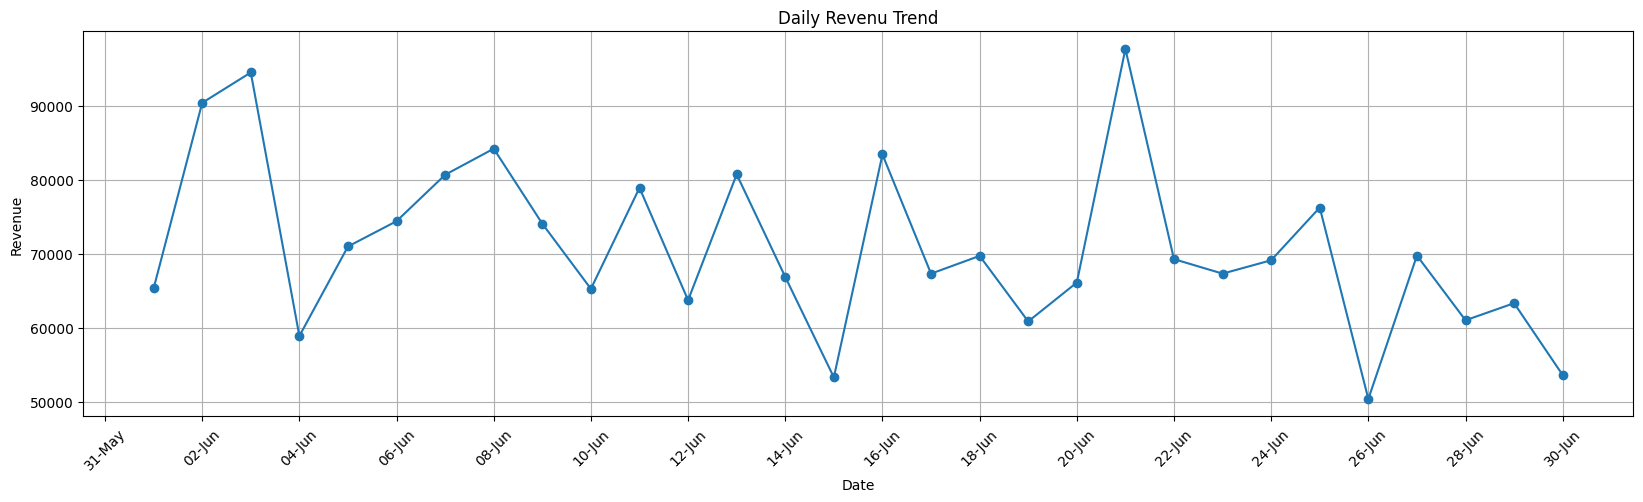

In [ ]:
# import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(20,5))
plt.plot(daily_sales.index, daily_sales.values, marker="o")
plt.title("Daily Revenu Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
df["Order Date"].dt.month.value_counts().sort_index()
df_june["Order Date"].min(), df_june["Order Date"].max()

(Timestamp('2026-06-01 00:00:00'), Timestamp('2026-06-30 00:00:00'))

#### 2) Daily Orders Trend

In [ ]:
June_date = df[df["Order Date"].dt.month == 6].copy()

daily_sales = (
    June_date.groupby("Order Date")["Order ID"].nunique().reset_index()
)
daily_sales.columns=["Orders Date", "Total Orders"]



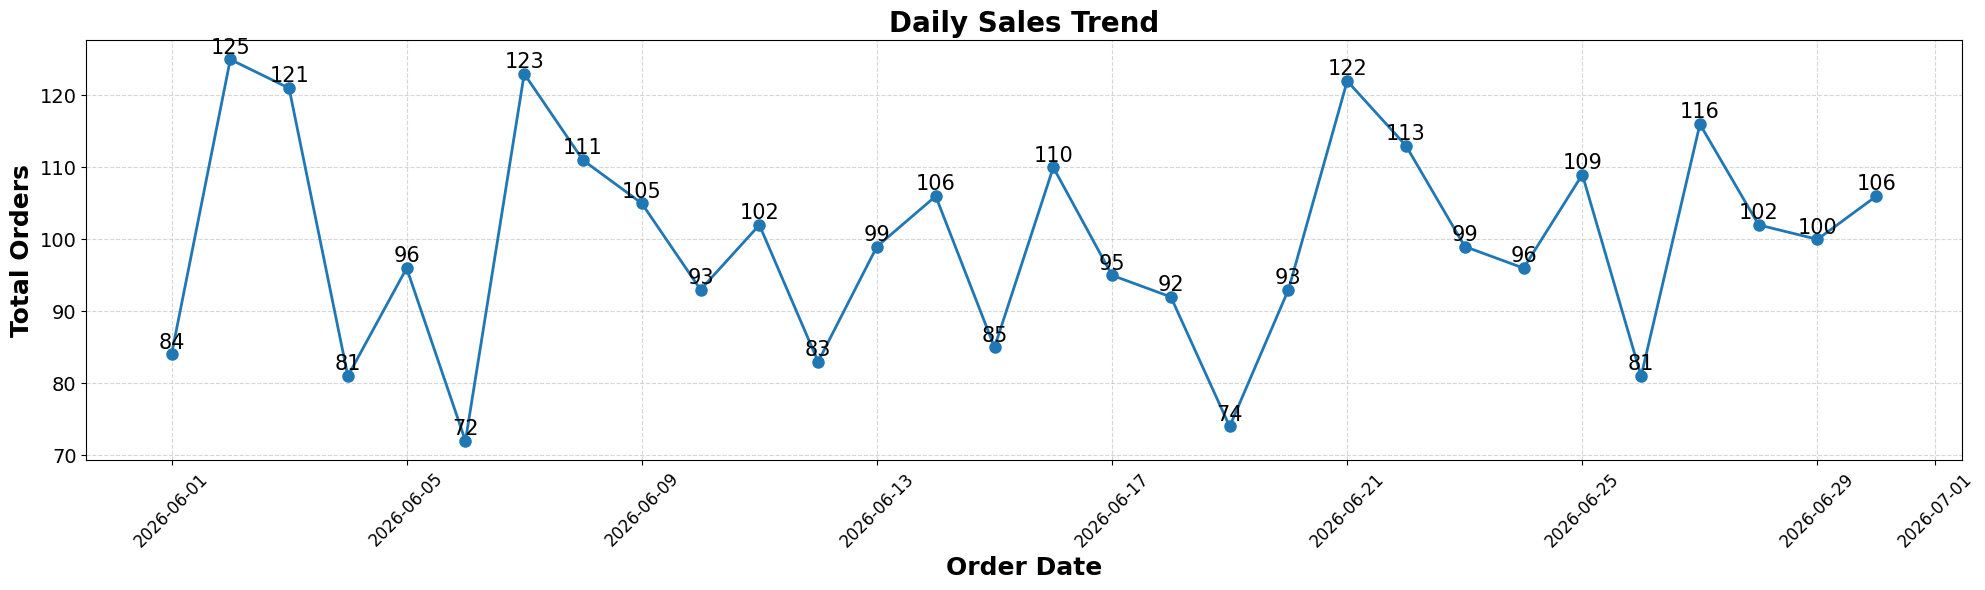

In [ ]:
plt.figure(figsize=(20,6))
plt.plot(
    daily_sales["Orders Date"],
    daily_sales["Total Orders"],
    marker="o",
    markersize=8,
    linewidth =2 
)
# Data lables 
for x,y in zip(daily_sales["Orders Date"], daily_sales["Total Orders"]):
    plt.text(
        x, y+0.8,
        str(y),
        fontsize = 15 , 
        ha = "center"
    )

plt.title("Daily Sales Trend",fontsize = 20, fontweight="bold")
plt.xlabel("Order Date",fontsize = 18,fontweight = "bold")
plt.ylabel("Total Orders",fontsize=18,fontweight = "bold")

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=14)
plt.grid(True,linestyle="--",alpha = 0.5)
plt.tight_layout()
plt.show()



#### 3) Daily  Revenue Trend 

In [ ]:
daily_revenue = (
    June_date.groupby("Order Date")["Price after discount"].sum().reset_index()
)
daily_revenue.columns= ["Order Date","Revenue"]
daily_revenue.head()

,Order Date,Revenue
0,2026-06-01,65301.0
1,2026-06-02,90361.0
2,2026-06-03,94457.0
3,2026-06-04,58877.0
4,2026-06-05,70966.0


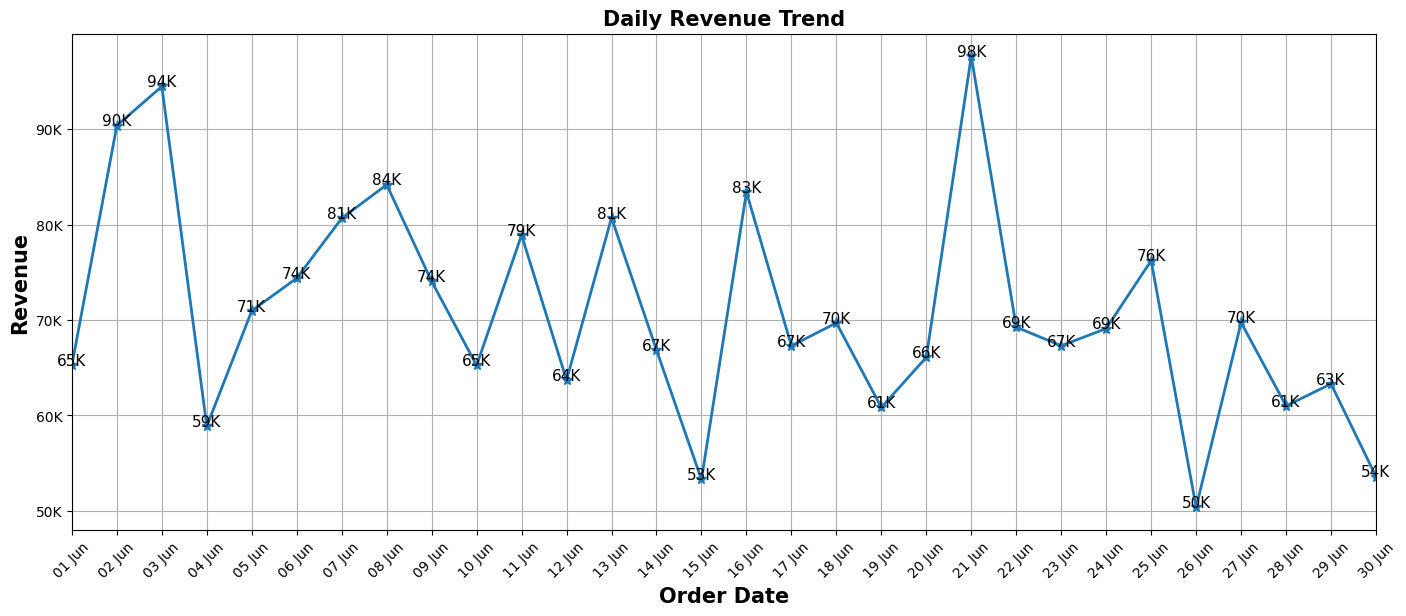

In [ ]:
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates 


plt.figure(figsize=(14,6))
plt.plot(daily_revenue["Order Date"],daily_revenue["Revenue"], marker="*",markersize=8,linewidth=2)

# enable data lables 
for x,y in zip(daily_revenue["Order Date"],daily_revenue["Revenue"]):
    plt.text(
        x, y+0.8,
        f"{y/1000:.0f}K",
        fontsize=11,
        ha="center"
        )

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

ax = plt.gca()

# show very date from 1 to 30 jun
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# format as jun 01 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))


plt.title("Daily Revenue Trend",fontsize=15,fontweight="bold")
plt.xlabel("Order Date",fontsize=15,fontweight="bold")
plt.ylabel("Revenue",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)

plt.xlim(
    daily_revenue["Order Date"].min(),
    daily_revenue["Order Date"].max()
)

plt.show()

#### 4) Weekly Orders Trend
##### Q) Which week of June received the highest number of orders?

In [ ]:
df_june["Week"] = pd.cut(
    df_june["Order Date"].dt.day,
    bins=[0, 7, 14, 21, 30],
    labels=["Week 1", "Week 2", "Week 3", "Week 4"]
)
Weekly_orders = (
    df_june.groupby("Week")["Order ID"].nunique().reset_index()
)
Weekly_orders.columns = ["Week","Total Orders"]
Weekly_orders

,Week,Total Orders
0,Week 1,700
1,Week 2,697
2,Week 3,670
3,Week 4,919


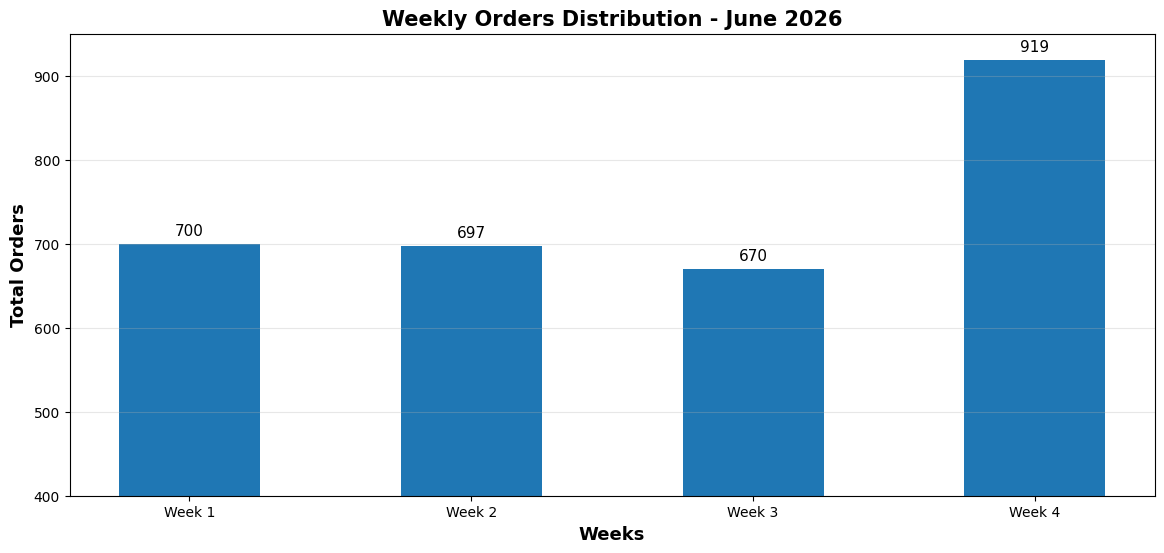

In [ ]:
plt.figure(figsize=(14,6))
plt.bar(x=Weekly_orders["Week"],height=Weekly_orders["Total Orders"],width=0.5)

# data lables 
for x,y in zip(Weekly_orders["Week"],Weekly_orders["Total Orders"]):
    plt.text(
        x, y+10,
        str(y),
        fontsize=11,
        ha="center"
    )

plt.title("Weekly Orders Distribution - June 2026",fontsize=15,fontweight="bold")
plt.xlabel("Weeks",fontsize=13,fontweight="bold")
plt.ylabel("Total Orders",fontsize=13,fontweight="bold")
plt.ylim(400,950)
plt.grid(axis="y",alpha=0.3)
plt.show()

#### 5) Weekday vs Weekend Analysis
##### Q) Are more orders and revenue generated on weekdays or weekends?

In [ ]:
df_june["Day Name"] = df_june['Order Date'].dt.day_name()
df_june['Day Type'] = df_june['Day Name'].apply(
    lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday"
)
df_june[["Order Date","Day Name","Day Type"]].head(10)

,Order Date,Day Name,Day Type
1,2026-06-05,Friday,Weekday
2,2026-06-07,Sunday,Weekend
3,2026-06-07,Sunday,Weekend
4,2026-06-05,Friday,Weekday
5,2026-06-02,Tuesday,Weekday
6,2026-06-06,Saturday,Weekend
7,2026-06-02,Tuesday,Weekday
8,2026-06-02,Tuesday,Weekday
9,2026-06-02,Tuesday,Weekday
10,2026-06-02,Tuesday,Weekday


In [ ]:
weekday_weekend = (
    df_june.groupby("Day Type").agg(
        Total_Orders = ("Order ID","nunique"),
        Total_Revenue = ("Price after discount","sum")
    )
    .reset_index()
)
weekday_weekend

,Day Type,Total_Orders,Total_Revenue
0,Weekday,2148,1529727.0
1,Weekend,831,597056.0


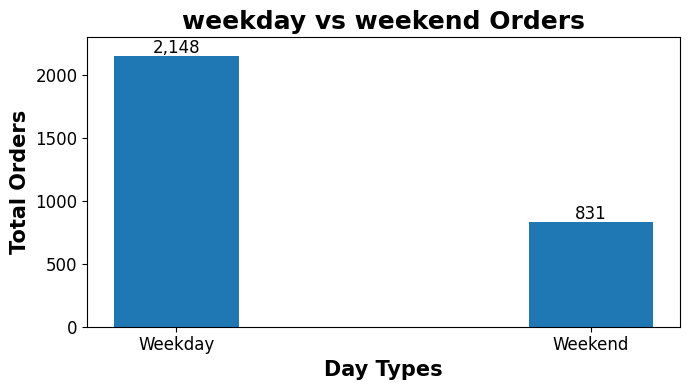

In [ ]:

plt.figure(figsize=(7,4))
plt.bar(weekday_weekend["Day Type"],weekday_weekend["Total_Orders"],width=0.3)
plt.title("weekday vs weekend Orders",fontsize=18,fontweight="bold")
plt.xlabel("Day Types",fontsize=15,fontweight="bold")
plt.ylabel("Total Orders",fontsize=15,fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,2300)

# Data labels 
for x,y in zip(weekday_weekend["Day Type"],weekday_weekend["Total_Orders"]):
    plt.text(
        x,y+25,
        f"{y:,}",
        fontsize=12,
        ha="center"
    )
plt.tight_layout()
plt.show()

#### 6) Top 10 Best-Selling Products 
##### Q) Which products received the highest number of customer orders in June 2026?

In [ ]:
top_products = (
    df_june.groupby("SKU")
    .agg(
        Total_Quantity=("Item Quantity", "sum"),
        Total_Revenue=("Price after discount", "sum")
    )
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
    .reset_index()
)
top_products

,SKU,Total_Quantity,Total_Revenue
0,SKU:210x110-squaredesign,173.0,132252.0
1,SKU:TG_thmac_des-205x100,116.0,89679.0
2,SKU:TG_smexf_bl30x30,100.0,12203.0
3,SKU:TG_smexf_bl30x25,95.0,10453.0
4,SKU:TG_thmac_des-210x100,62.0,47642.0
5,SKU:browntape011,61.0,8224.0
6,SKU:TG_thmac_des-200x90,59.0,47258.0
7,SKU:wlb_185*90cms_brwn,47.0,29030.0
8,SKU:black024,44.0,15062.0
9,SKU:TG_thmac_des-200x100,44.0,33153.0


In [ ]:
### shortening the product title 
top_products["Clean SKU"]=(
    top_products["SKU"].str.replace("SKU:","")
)

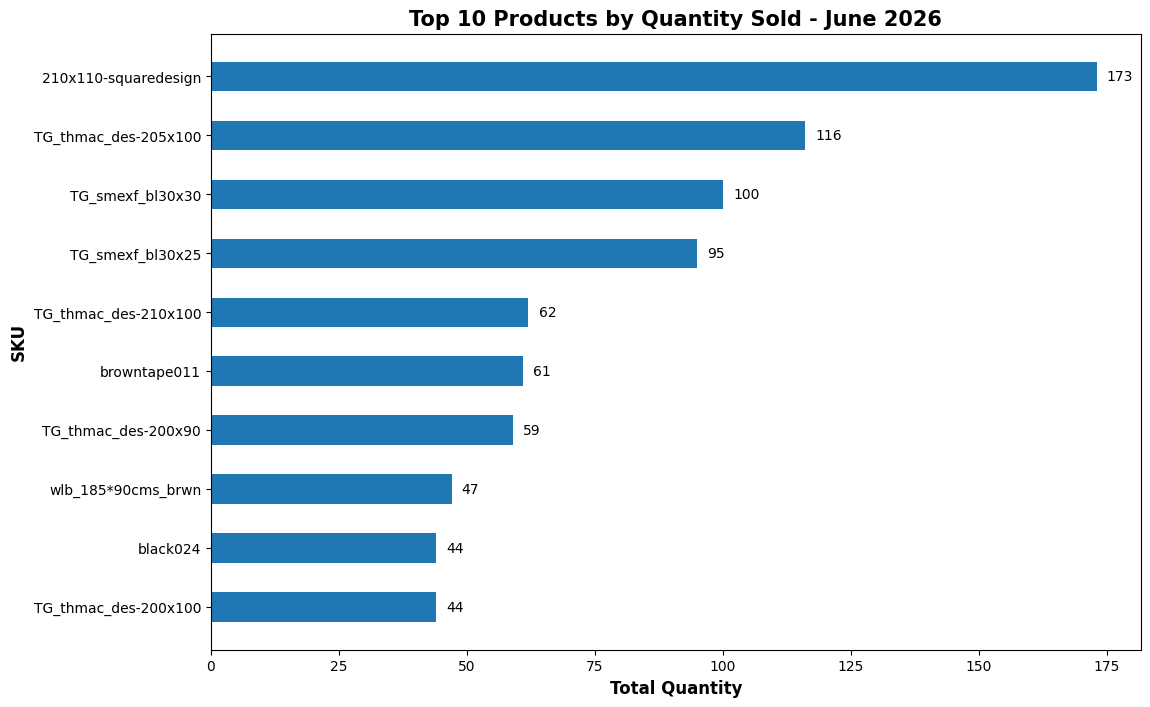

In [ ]:
plt.figure(figsize=(12,8))
plt.barh(top_products["Clean SKU"],top_products["Total_Quantity"],height=0.5)
plt.title("Top 10 Products by Quantity Sold - June 2026", fontsize=15,fontweight="bold")

for x,y in zip(top_products["Clean SKU"],top_products["Total_Quantity"]):
    plt.text(
        y + 2,
        x,
        int(y),
        va="center",
        fontsize=10
    )

plt.xlabel("Total Quantity",fontsize=12,fontweight="bold")
plt.ylabel("SKU",fontsize=12,fontweight="bold")
plt.gca().invert_yaxis()
plt.show()

#### 7) Top 10 Products by Revenue
##### Q) Which products generated the highest revenue in June 2026?

In [ ]:
top_revenue = (
    df_june.groupby("SKU")
    .agg(
    Total_Revenue=("Price after discount","sum")
)
.sort_values("Total_Revenue",ascending=False)
.head(10)
.reset_index()
)
top_revenue["Clean SKU"] = (
    top_revenue["SKU"].str.replace("SKU:","")


)

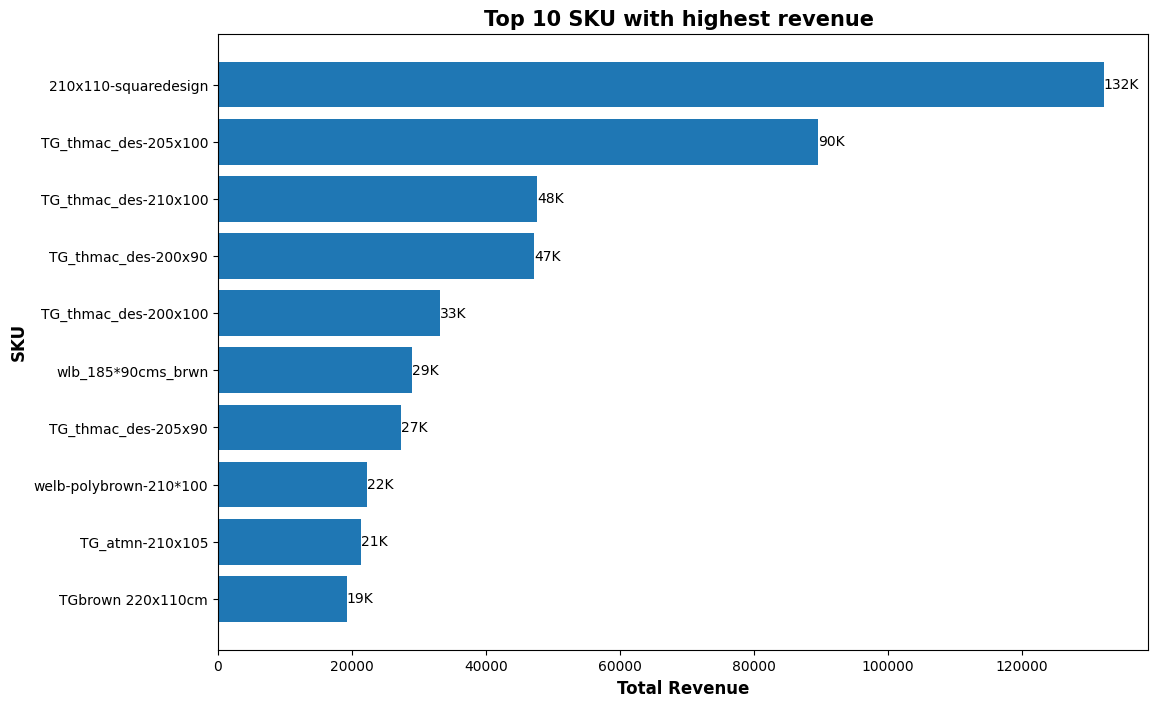

In [ ]:
plt.figure(figsize=(12,8))
plt.barh(top_revenue["Clean SKU"],top_revenue["Total_Revenue"])

for x,y in zip(top_revenue["Clean SKU"],top_revenue["Total_Revenue"]):
    plt.text(
        y + 2,
        x,
        f"{y/1000:.0f}K",
        fontsize=10,
        va = "center"
    )

plt.title("Top 10 SKU with highest revenue ",fontsize=15,fontweight="bold")
plt.xlabel("Total Revenue",fontsize=12,fontweight="bold")
plt.ylabel("SKU",fontsize=12,fontweight="bold")
plt.gca().invert_yaxis()
plt.show()

### 8) Compare Quantity vs Revenue
#### Q) Do the products that sell the most units also generate the highest revenue?

In [ ]:
# finding common sku 
common_SKU = set(top_products["Clean SKU"]) & set(top_revenue["Clean SKU"])
print(common_SKU)
print(f"Common SKU",{len(common_SKU)})

{'TG_thmac_des-210x100', '210x110-squaredesign', 'TG_thmac_des-205x100', 'TG_thmac_des-200x90', 'wlb_185*90cms_brwn', 'TG_thmac_des-200x100'}
Common SKU {6}


##### OutPut :

### Out of the Top 10 SKUs by Quantity Sold and the Top 10 SKUs by Revenue, 6 SKUs are common. This indicates that while several best-selling products are also the highest revenue generators, not all high-volume products contribute equally to revenue. Similarly, some products generate significant revenue despite selling fewer units, suggesting a higher selling price or premium positioning. Therefore, businesses should evaluate both sales volume and revenue together when making inventory, pricing, and marketing decisions.

### 9) and 10) State-wise Performance
#### Q) Which states generated the highest number of orders and revenue during June 2026?

In [ ]:
state_sales = (
    df_june.groupby("Customer's Delivery State")
    .agg(
        Total_Orders=("Order ID","nunique"),
        Total_Revenue=("Price after discount","sum")
    )
    .sort_values("Total_Orders",ascending=False)
    .head(10)
    .reset_index()
)

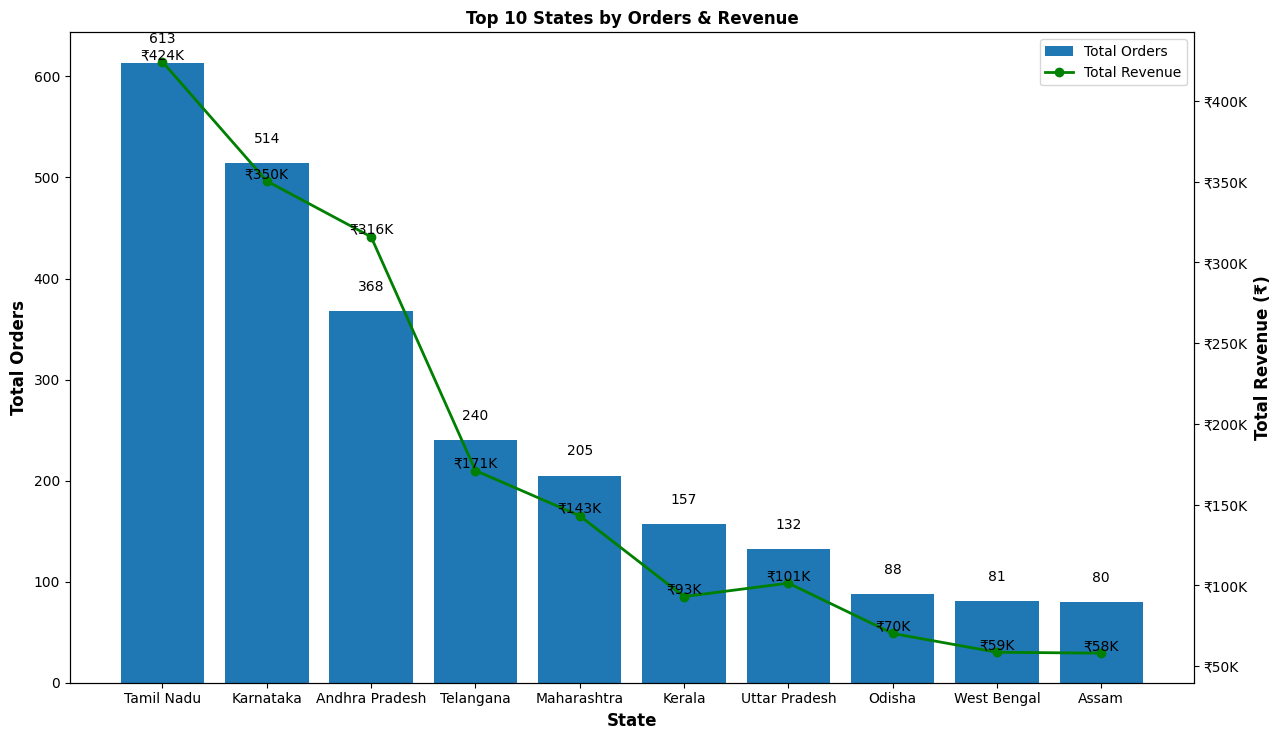

In [ ]:
fig,ax1 = plt.subplots(figsize=(13,7.5))

# Bar chart (Orders)

bars = ax1.bar(state_sales["Customer's Delivery State"],state_sales["Total_Orders"],label="Total Orders")

ax1.set_xlabel("State",fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Orders",fontsize=12, fontweight="bold")

# Data labels on bars 
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 20, 
        f"{int(height)}",
        ha="center",
        fontsize="10"
    )

# Second Y-axis
ax2 = ax1.twinx()

ax2.plot(
    state_sales["Customer\'s Delivery State"],
    state_sales["Total_Revenue"],
    color="green",
    marker="o",
    linewidth = 2,
    label ="Total Revenue"
)

# Revenue labels 
for x,y in zip(
    state_sales["Customer\'s Delivery State"],
    state_sales["Total_Revenue"]
):
    ax2.text(
        x,y+10,
        f"₹{y/1000:,.0f}K",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax2.set_ylabel("Total Revenue (₹)",fontsize=12,fontweight="bold")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.title("Top 10 States by Orders & Revenue",fontsize=12,fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()

# Format right Y-axis as K
from matplotlib.ticker import FuncFormatter

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1000:.0f}K")
)

plt.show()

#### Insight 

#### Tamil Nadu and Karnataka are the strongest-performing markets, leading in both order volume and revenue. Revenue generally follows the same pattern as order volume, indicating that states with higher demand also contribute the highest sales value. This suggests these states should remain priority markets for inventory planning and promotional campaigns.

#### 11) Fulfilment Type Analysis
##### Q) Which fulfilment method contributes the most to sales and customer orders?

In [ ]:
fulfilment_analysis = (
    df_june.groupby("Fulfilment Type")
    .agg(
        total_orders =("Order ID","nunique"),
        total_revenue =("Price after discount","sum")
        )
        .sort_values("total_orders",ascending=False)
        .reset_index()

)

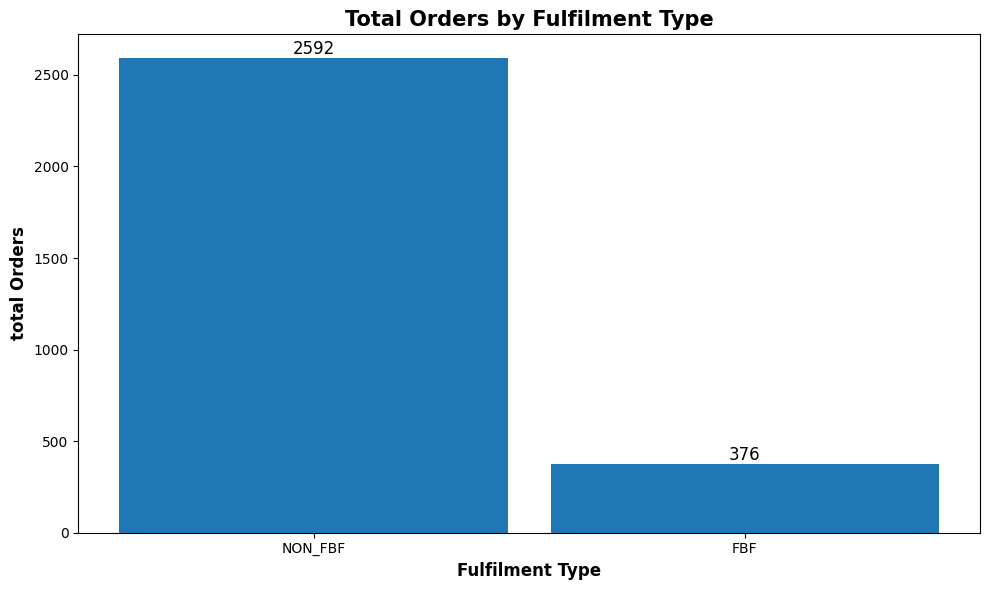

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(fulfilment_analysis["Fulfilment Type"],fulfilment_analysis["total_orders"],width =0.9)

for x,y in zip(fulfilment_analysis["Fulfilment Type"],fulfilment_analysis["total_orders"]):
    plt.text(
        x,y+20,
        str(y),
        fontsize=12,
        ha = "center"
    )

plt.title("Total Orders by Fulfilment Type",fontsize=15,fontweight="bold")
plt.xlabel("Fulfilment Type",fontsize=12,fontweight="bold")
plt.ylabel("total Orders",fontsize=12,fontweight="bold")
plt.tight_layout()
plt.show()

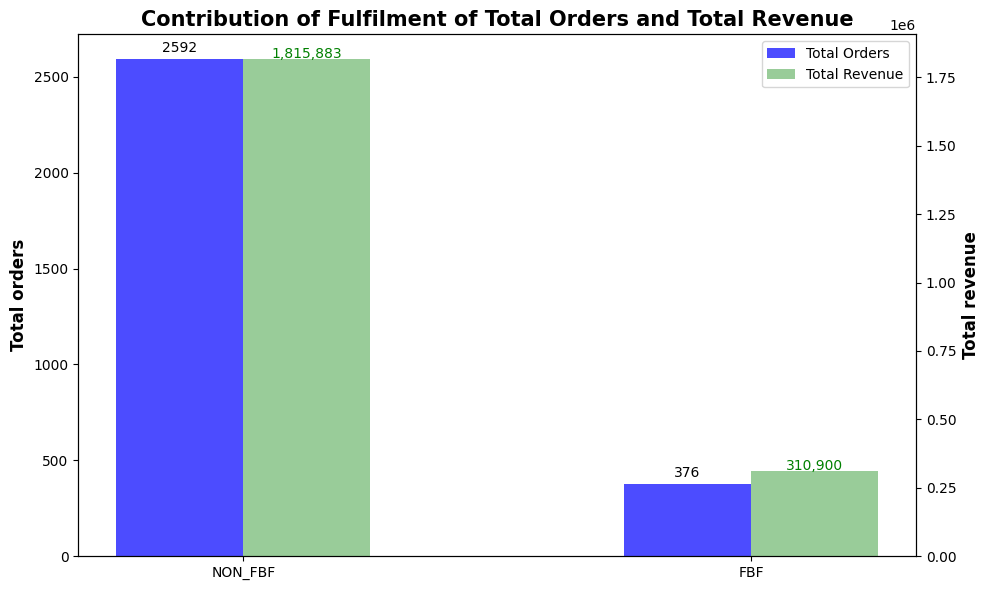

In [ ]:
import numpy as np 

x = np.arange(len(fulfilment_analysis))
width=0.25


fig, ax1 = plt.subplots(figsize=(10,6))

# blue bars - orders 
ax1.bar(
    x-width/2,
    fulfilment_analysis["total_orders"],
    color="blue",
    width=width,
    label="Total Orders",
    alpha = 0.7
)

for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+20,
        f'{int(bar.get_height())}',
        ha="center",
        va="bottom",
        fontsize=10
    )

ax1.set_ylabel("Total Orders",fontsize=12,fontweight="bold")

# green bars - revenue
ax2 = ax1.twinx()
ax2.bar(
    x + width/2,
    fulfilment_analysis["total_revenue"],
    color="green",
    label = "Total Revenue",
    width=width,
    alpha = 0.4
)

for bar in ax2.patches:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+ 20000,
        f'{bar.get_height():,.0f}',
        ha="center",
        va="center",
        fontsize=10,
        color="green"
    )

ax1.set_xticks(x)
ax1.set_xticklabels(fulfilment_analysis["Fulfilment Type"])

ax1.set_ylabel("Total orders",fontsize=12,fontweight="bold")
ax2.set_ylabel("Total revenue",fontsize=12,fontweight="bold")


plt.title("Contribution of Fulfilment of Total Orders and Total Revenue",fontsize=15,fontweight="bold")
plt.tight_layout()

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    fontsize=10
)

plt.show()

### Insight : 


Non-FBF is the primary fulfilment method, generating the highest number of orders and revenue. FBF contributes a relatively smaller share, indicating an opportunity for the business to assess increasing FBF adoption for eligible products to enhance operational efficiency and potentially improve sales performance

### 12) Top 10 States by Average Order Value (AOV)

In [ ]:
state_aov = (
    df_june.groupby("Customer's Delivery State")
    .agg(
        Total_orders=("Order ID","nunique"),
        Total_revenue=("Price after discount","sum")
    )
)
# calculating avg order value 
state_aov["avg_order_value"]=(
    state_aov["Total_revenue"]/state_aov["Total_orders"]
)

#filtering state with atleast 30 orders 
state_aov = state_aov[state_aov["Total_orders"]>=30]

state_aov = (
    state_aov.sort_values("avg_order_value",ascending=False)
    .head(10)
    .reset_index()
)
state_aov

,Customer's Delivery State,Total_orders,Total_revenue,avg_order_value
0,Rajasthan,43,40952.0,952.372093
1,Andhra Pradesh,368,315854.0,858.298913
2,Odisha,88,70288.0,798.727273
3,Bihar,43,33885.0,788.023256
4,Uttar Pradesh,132,101423.0,768.356061
5,Assam,80,58084.0,726.050000
6,West Bengal,81,58640.0,723.950617
7,Telangana,240,171163.0,713.179167
8,Chhattisgarh,31,21891.0,706.161290
9,Maharashtra,205,143147.0,698.278049


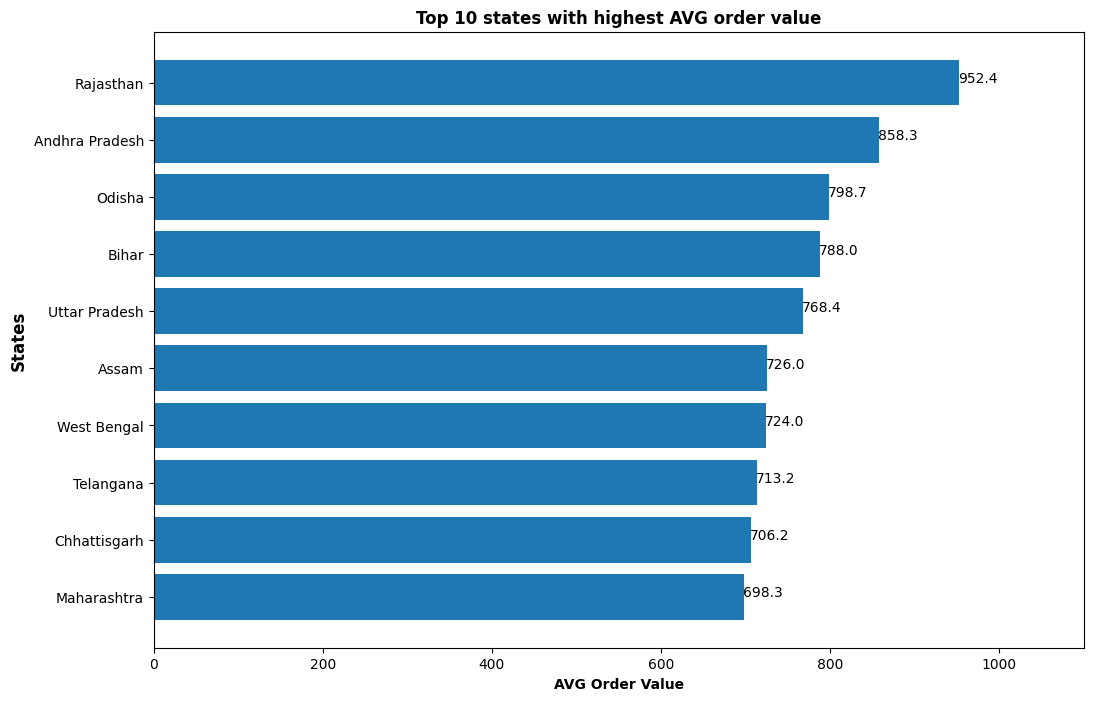

In [ ]:
plt.figure(figsize=(12,8))
plt.barh(state_aov["Customer\'s Delivery State"],state_aov["avg_order_value"])
plt.title("Top 10 states with highest AVG order value",fontsize=12,fontweight="bold")

for x,y in zip(state_aov["Customer\'s Delivery State"],state_aov["avg_order_value"]):
    plt.text(
        y+22,
        x,
        f"{y:.1f}",
        ha="center",
        fontsize=10
    )

plt.xlabel("AVG Order Value",fontsize=10,fontweight="bold")
plt.ylabel("States",fontsize=12,fontweight="bold")
plt.xlim(0, 1100)
plt.gca().invert_yaxis()
plt.show()

Insight:

Business Insight: Rajasthan recorded the highest Average Order Value (AOV) of ₹952 among states with at least 30 orders, indicating that customers in Rajasthan tend to spend more per order than those in other major states. Andhra Pradesh also demonstrated a strong AOV (₹858) while maintaining a high order volume, making it one of the most valuable markets. In contrast, Tamil Nadu and Karnataka generated a larger number of orders but had comparatively lower AOVs, suggesting that customers in these states place more frequent but lower-value orders on average.

#### 13) Perfomance by Order Type

In [ ]:
order_type_performance = (
    df_june.groupby("Order Type")
    .agg(
        total_orders = ("Order ID","nunique"),
        total_revenue = ("Price after discount","sum")
    )
    .sort_values("total_revenue",ascending=False)
    .reset_index()  
)

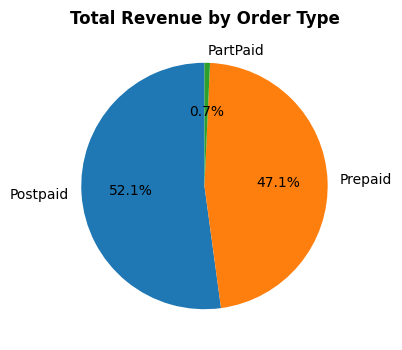

In [ ]:
plt.figure(figsize=(4,4))
plt.pie(order_type_performance["total_revenue"],
        labels=order_type_performance["Order Type"],
        autopct="%1.1f%%",
        startangle=90    
    )

plt.title("Total Revenue by Order Type",fontsize=12,fontweight="bold")
plt.show()

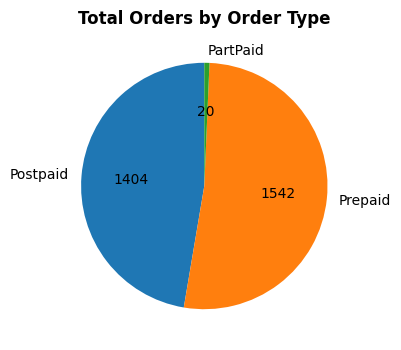

In [ ]:
total = order_type_performance["total_orders"].sum()
plt.figure(figsize=(4,4))
plt.pie(
        order_type_performance["total_orders"],
        labels=order_type_performance["Order Type"],
        autopct=lambda pct: f"{int(round(pct * total / 100))}",
        startangle=90    
    )
plt.title("Total Orders by Order Type",fontsize=12,fontweight="bold")
plt.show()


Insight:

1. Prepaid account for 1542 orders and Postpaid account for 1404 orders ,  perform equally towards gaining Orders.
   By this we get know that customers are confortable with both the payment methods.
2. Prepaid contributes 52.1% in revenue generating where as Postpaid contributes 47.1% in revenue generating.
3. PartPaid has a negligible business contribution with 20 orders and 0.7% of total revenue. The company can continue supporting this if it is required but company has to focus on Prepaid and Postpaid for the better Business Growth.

#### 14)  Pareto Anlysis
##### Q) Which products (or SKUs) contribute to approximately 80% of the total revenue, and how can the company use this information to optimize inventory, marketing, and sales strategies?

In [ ]:
pareto = (
    df_june.groupby("SKU")
    .agg(
        total_revenue = ("Price after discount","sum")
    )
    .sort_values("total_revenue",ascending=False)
    .reset_index()
    .head(10)
)
pareto["SKU"] = pareto["SKU"].str.replace("SKU:","")


In [ ]:
pareto["Revenue %"]=(
    (pareto["total_revenue"] / pareto["total_revenue"].sum() * 100).round(2)
)
pareto["Cumulative %"]= pareto["Revenue %"].cumsum().round(2).head(10)

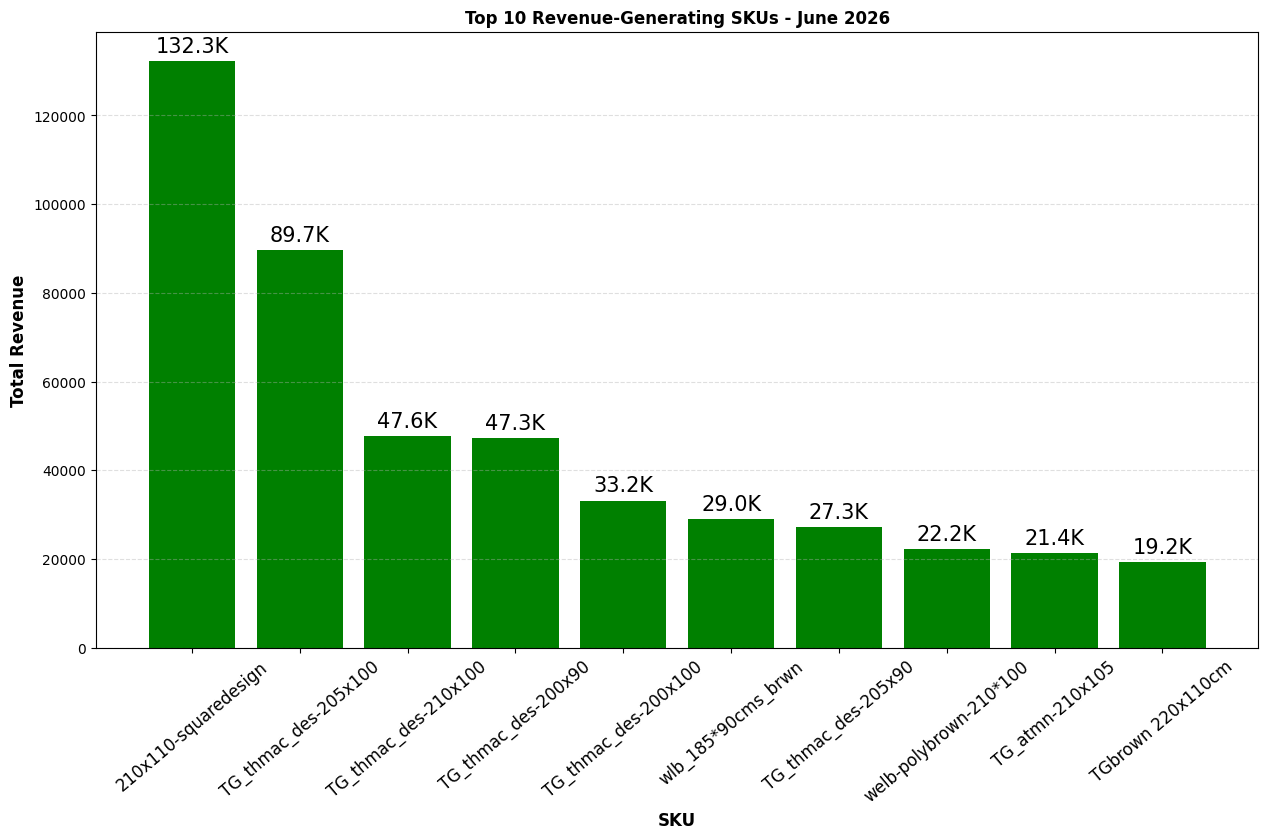

In [ ]:
plt.figure(figsize=(15,8))
plt.bar(pareto["SKU"],pareto["total_revenue"],color="green")

for x,y in zip(pareto["SKU"],pareto["total_revenue"]):
    plt.text(
        x,y+2000,
        f"{y/1000:.1f}K",
        fontsize=15,
        ha="center"
    )

plt.title("Top 10 Revenue-Generating SKUs - June 2026",fontsize=12,fontweight="bold")
plt.xlabel("SKU",fontsize=12,fontweight="bold")
plt.ylabel("Total Revenue",fontsize=12,fontweight="bold")
plt.xticks(rotation=40,fontsize=12)
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)
plt.show()

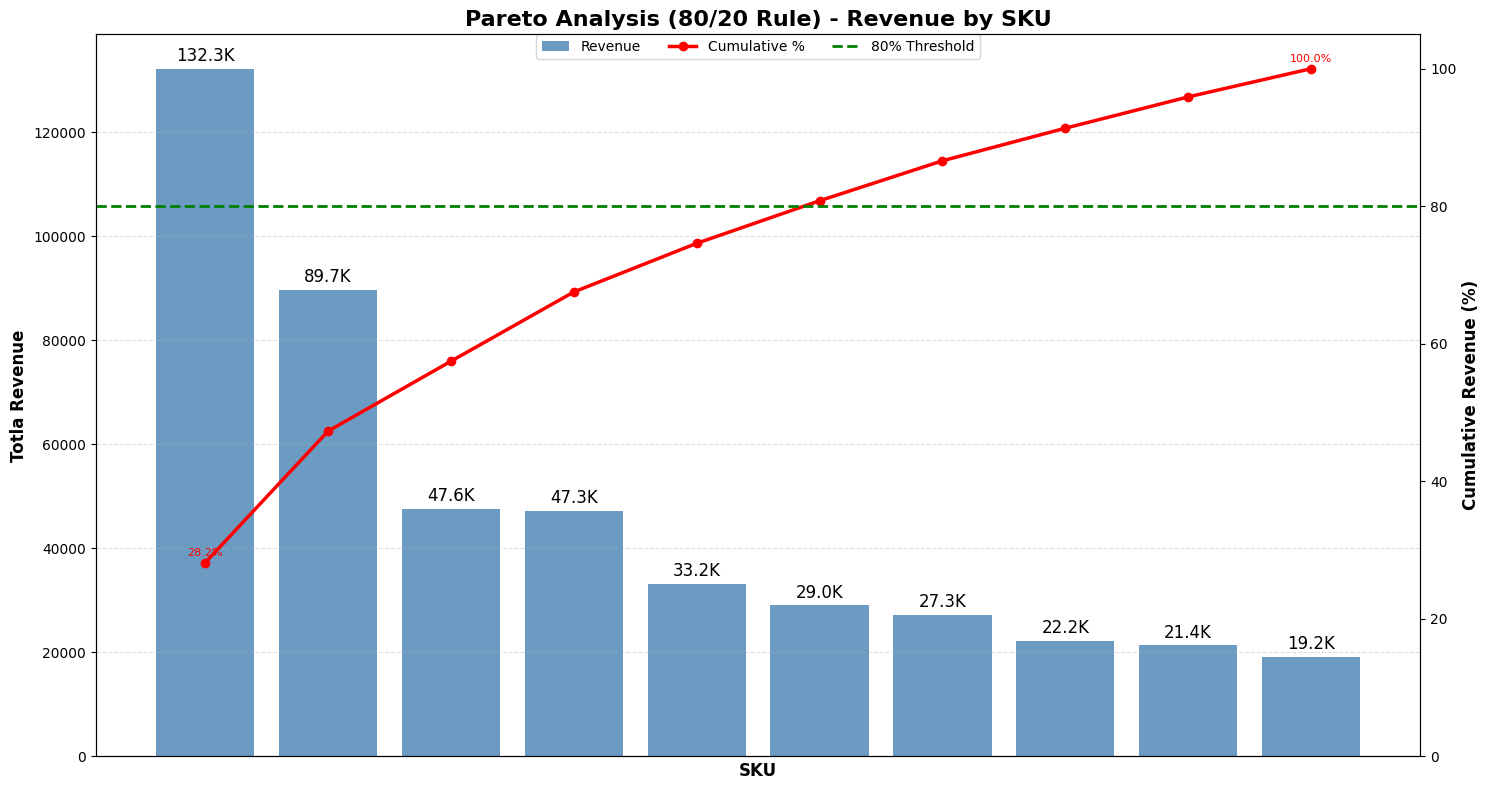

In [ ]:
fig, ax1 = plt.subplots(figsize=(15,8))
bars = ax1.bar(
    pareto["SKU"],
    pareto["total_revenue"],
    color="steelblue",
    alpha=0.8,
    label="Revenue"
)

for i, bar in enumerate(bars):
    if i < 10 :
         # only first 10 bars 
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f"{bar.get_height()/1000:.1f}K",
            ha="center",
            fontsize=12
        )

ax1.set_xlabel("SKU",fontsize=12,fontweight="bold")
ax1.set_ylabel("Totla Revenue",fontsize=12,fontweight="bold")

ax2=ax1.twinx()

ax2.plot(
    pareto["SKU"],
    pareto["Cumulative %"],
    color="red",
    marker="o",
    linewidth=2.5,
    label="Cumulative %"
)

for i,(x,y) in enumerate(zip(pareto["SKU"],pareto["Cumulative %"])):
    if i % 20 == 0 or i == len(pareto)-1 :
        ax2.text(
        x,
        y+1,
        f"{y:.1f}%",
        fontsize=8,
        color="red",
        ha="center"
        )

ax2.axhline(
    y=80,
    color="green",
    linestyle="--",
    linewidth=2,
    label="80% Threshold"
)

ax2.set_ylabel(
    "Cumulative Revenue (%)",
    fontsize=12,
    fontweight="bold"
)
ax2.set_ylim(0,105)
plt.xticks([])
ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.title(
    "Pareto Analysis (80/20 Rule) - Revenue by SKU",
    fontsize=16,
    fontweight="bold"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True,
    fontsize=10
)
plt.tight_layout()
plt.show()

Insight :
 
The Pareto Analysis revealed that a relatively small percentage of products contributes to nearly 80% of the total revenue, confirming the 80/20 principle. These high-performing products are the primary revenue drivers and should be prioritized for inventory planning, stock availability, marketing campaigns, and pricing strategies. On the other hand, products contributing less to overall revenue should be reviewed for demand, profitability, and inventory optimization to reduce holding costs and improve overall business performance.

#### 15) Discount Impact Analysis
##### Q) How do discounts influence sales performance, and which products or SKUs receive the highest discounts? Does offering higher discounts lead to increased sales quantity and revenue?

In [ ]:
total_discount = df_june["Price before discount"].sum()
avg_discount_order = (
    df_june.groupby("Order ID")["Price before discount"]
    .sum()
    .mean()
)

discount_percentage = (
    total_discount / 
    df_june["Price before discount"].sum()
)* 100 
print(f"total Discount Given: ,{total_discount}")
print(f"Avg Discount Per Order: ,{avg_discount_order}")
print(f"Discount Percentage %: ,{discount_percentage}")

total Discount Given: ,2256400.0
Avg Discount Per Order: ,760.7552258934592
Discount Percentage %: ,100.0


In [ ]:
discount_sku = (
    df_june.groupby("SKU")
    .agg(
        Total_Discount=("Price before discount","sum"),
        Revenue=("Price after discount","sum"),
        Quantity=("Item Quantity","sum")
    )
    .sort_values("Total_Discount",ascending=False)
    .head(10)
    .reset_index()
)

discount_sku["SKU"] = discount_sku["SKU"].str.replace("SKU:","",regex=False)
discount_sku

,SKU,Total_Discount,Revenue,Quantity
0,210x110-squaredesign,146721.0,132252.0,173.0
1,TG_thmac_des-205x100,98288.0,89679.0,116.0
2,TG_thmac_des-210x100,52624.0,47642.0,62.0
3,TG_thmac_des-200x90,49978.0,47258.0,59.0
4,TG_thmac_des-200x100,37200.0,33153.0,44.0
5,wlb_185*90cms_brwn,30372.0,29030.0,47.0
6,TG_thmac_des-205x90,27857.0,27265.0,33.0
7,TG_atmn-210x105,23369.0,21367.0,35.0
8,welb-polybrown-210*100,23146.0,22245.0,35.0
9,TG_atmn-210x90,20216.0,18445.0,30.0


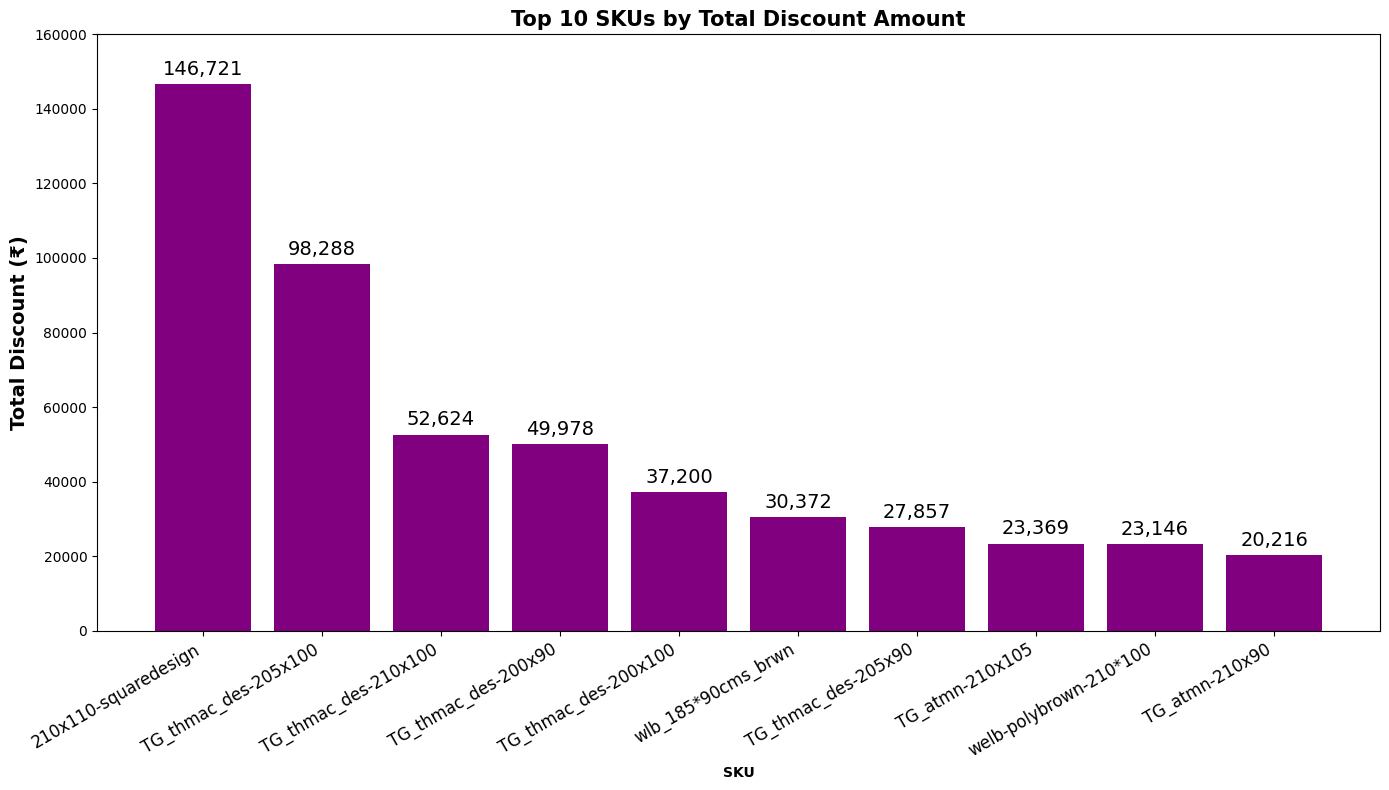

In [ ]:
plt.figure(figsize=(14,8))
bars = plt.bar(
    discount_sku["SKU"],
    discount_sku["Total_Discount"],
    color="purple"
)

for bar in bars:
    plt.text(
       bar.get_x() + bar.get_width()/2,
       bar.get_height()+2500,
       f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=14
    )

plt.title("Top 10 SKUs by Total Discount Amount",fontsize=15,fontweight="bold")
plt.xlabel("SKU",fontweight="bold")
plt.ylabel("Total Discount (₹)",fontsize=14,fontweight="bold")
plt.xticks(rotation=30,ha="right",fontsize=12)
plt.ylim(0, 160000)
plt.tight_layout()
plt.show()

Insight : 

The SKU 210x110-squaredesign received the highest total discount (₹146,721), followed by TG_thmac_des-205x100 (₹98,288). Interestingly, these SKUs also rank among the highest in revenue and quantity sold, indicating that promotional discounts were primarily offered on high-demand products. This suggests that discounts were strategically applied to boost sales volume while maintaining strong revenue generation.

### Scatter Plot 1: Discount vs Revenue

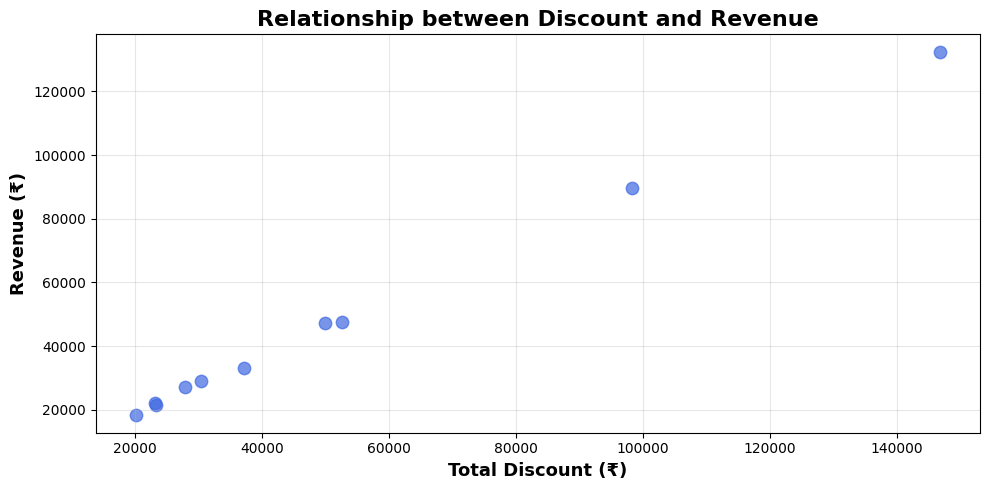

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(
    discount_sku["Total_Discount"],
    discount_sku["Revenue"],
    s=80,
    alpha=0.7,
    color="royalblue"
)

plt.title(
    "Relationship between Discount and Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Discount (₹)", fontsize=13, fontweight="bold")
plt.ylabel("Revenue (₹)", fontsize=13, fontweight="bold")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot 2: Discount vs Quantity Sold

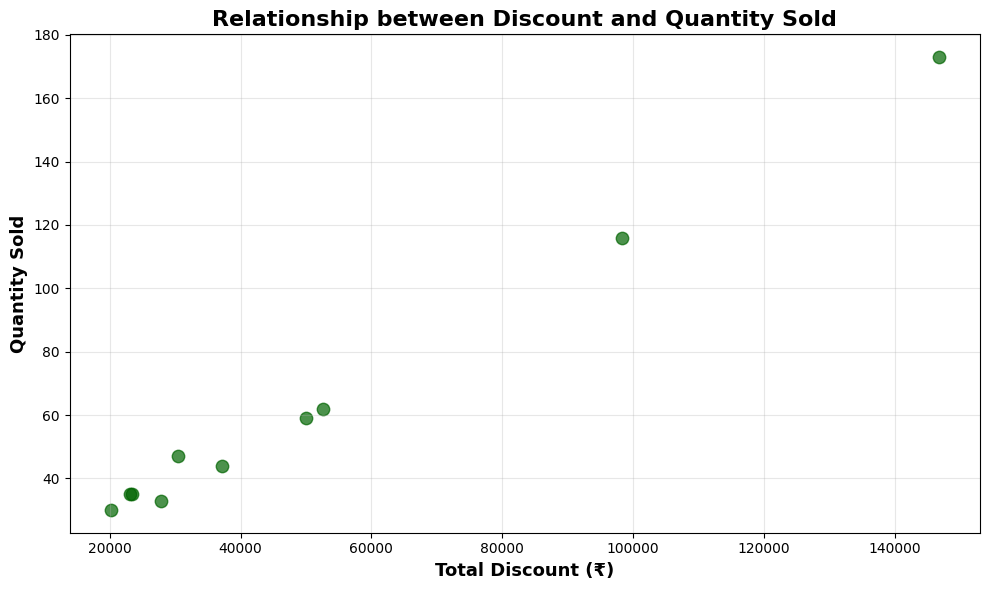

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    discount_sku["Total_Discount"],
    discount_sku["Quantity"],
    s=80,
    alpha=0.7,
    color="darkgreen"
)

plt.title(
    "Relationship between Discount and Quantity Sold",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Discount (₹)", fontsize=13, fontweight="bold")
plt.ylabel("Quantity Sold", fontsize=13, fontweight="bold")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
corr_discount_revenue = discount_sku["Total_Discount"].corr(
    discount_sku["Revenue"]
)

corr_discount_quantity = discount_sku["Total_Discount"].corr(
    discount_sku["Quantity"]
)

print("Correlation (Discount vs Revenue):", round(corr_discount_revenue, 3))
print("Correlation (Discount vs Quantity):", round(corr_discount_quantity, 3))

Correlation (Discount vs Revenue): 1.0
Correlation (Discount vs Quantity): 0.997


Insight : 

The analysis shows a very strong positive correlation between total discount and revenue (1.000), as well as between total discount and quantity sold (0.997). High-selling SKUs also received higher cumulative discounts and generated higher revenue. This suggests that discounts were primarily concentrated on high-demand products, supporting increased sales volume while maintaining strong revenue performance. However, since the analysis uses aggregated SKU-level totals, the results indicate association rather than proving that discounts alone caused the increase in sales.

In [ ]:
type(discount_sku)

pandas.DataFrame

In [ ]:
order_type_performance.columns

Index(['Order Type', 'total_orders', 'total_revenue'], dtype='str')

In [ ]:
df_june.columns

Index(['Order ID', 'Product Title', 'FSN', 'SKU', 'Event Sub Type',
       'Order Type', 'Fulfilment Type', 'Order Date', 'Item Quantity',
       'Price before discount', 'Total Discount', 'Price after discount',
       'Shipping Charges', 'Final Invoice Amount', 'Buyer Invoice ID',
       'Customer's Billing State', 'Customer's Delivery State', 'Week',
       'Day Name', 'Day Type'],
      dtype='str')

In [ ]:
print(df_june.shape)

NameError: name 'df_june' is not defined